In [58]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = np.random.randint(600, 701)

states = [
    "Maharashtra", "Gujarat", "Madhya Pradesh",
    "Karnataka", "Telangana", "Rajasthan",
    "Uttar Pradesh", "Bihar", "Odisha", "Tamil Nadu","New Delhi"," Punjab", "Haryana"
]

districts = [
    "Pune", "Mumbai", "Nashik", "Nagpur", "Ahmednagar",
    "Satara", "Kolhapur", "Thane", "Aurangabad",
    "Solapur", "Nanded", "Sangli", "Nagaur", "Ajmer", "Surat","jaisalmer"," Chattarpur (Delhi)","Vadodara","Ludhiana", "Amritsar","Kapurtala",
    "Varanasi", " Mangaluru", "Udupi", "Darbhanga", "Bhagalpur", "Patna", " Nizamabad"," Indore"," Bhopal","Coimbtore","Chennai","Karnal","Ambala",
    "Panipat","Sonipat","Agra","Kanpur","Puri","Sarai Rohilla (Delhi)", "Gurugram","Noida", "patiyala"
]

project_types = [
    "National Highway",
    "State Highway",
    "Railway",
    "Metro",
    "Industrial Corridor",
    "Airport",
    "Dam",
    "Expressway"
]

land_types = [
    "Agricultural",
    "Residential",
    "Commercial",
    "Industrial",
    "Forest",
    "Government"
]

owner_types = [
    "Individual",
    "Joint Family",
    "Company",
    "Government",
    "Trust"
]

consent_statuses = [
    "Pending",
    "Obtained",
    "Disputed"
]

compensation_statuses = [
    "Pending",
    "Partial",
    "Paid"
]

approval_statuses = [
    "Pending",
    "Approved",
    "Rejected"
]

rehabilitation_statuses = [
    "Not Required",
    "Pending",
    "In Progress",
    "Completed"
]

grievance_statuses = [
    "None",
    "Open",
    "Resolved"
]

dispute_levels = [
    "None",
    "Low",
    "Medium",
    "High"
]

data = {
    "land_id": [
        f"LA{2026}{i:04d}"
        for i in range(1, n + 1)
    ],

    "state": np.random.choice(states, n),

    "district": np.random.choice(districts, n),

    "city_village": [
        f"Village_{np.random.randint(1, 101)}"
        for _ in range(n)
    ],

    "project_type": np.random.choice(
        project_types, n
    ),

    "land_area_acres": np.round(
        np.random.uniform(0.5, 50, n), 2
    ),

    "land_type": np.random.choice(
        land_types, n
    ),

    "owner_type": np.random.choice(
        owner_types, n
    ),

    "owners_count": np.random.randint(
        1, 8, n
    ),

    "ownership_dispute": np.random.choice(
        ["Yes", "No"],
        n,
        p=[0.25, 0.75]
    ),

    "dispute_level": np.random.choice(
        dispute_levels,
        n,
        p=[0.55, 0.15, 0.20, 0.10]
    ),

    "notice_issued": np.random.choice(
        ["Yes", "No"],
        n,
        p=[0.85, 0.15]
    ),

    "consent_status": np.random.choice(
        consent_statuses,
        n,
        p=[0.35, 0.55, 0.10]
    ),

    "valuation_amount": np.round(
        np.random.uniform(2, 200, n) * 100000,
        0
    ),

    "compensation_amount": np.round(
        np.random.uniform(2, 250, n) * 100000,
        0
    ),

    "compensation_status": np.random.choice(
        compensation_statuses,
        n,
        p=[0.30, 0.20, 0.50]
    ),

    "payment_delay_days": np.random.randint(
        0, 181, n
    ),

    "approval_status": np.random.choice(
        approval_statuses,
        n,
        p=[0.30, 0.65, 0.05]
    ),

    "approval_delay_days": np.random.randint(
        0, 151, n
    ),

    "rehabilitation_status": np.random.choice(
        rehabilitation_statuses,
        n,
        p=[0.45, 0.20, 0.15, 0.20]
    ),

    "grievance_status": np.random.choice(
        grievance_statuses,
        n,
        p=[0.55, 0.20, 0.25]
    ),

    "acquisition_percent": np.round(
        np.random.uniform(5, 100, n), 2
    ),

    "total_delay_days": np.random.randint(
        0, 365, n
    )
}

df = pd.DataFrame(data)

# Calculate acquisition status
def get_status(x):
    if x < 25:
        return "Initial"
    elif x < 50:
        return "In Progress"
    elif x < 80:
        return "Advanced"
    elif x < 100:
        return "Near Completion"
    else:
        return "Completed"

df["acquisition_status"] = (
    df["acquisition_percent"].apply(get_status)
)

# Risk calculation
def calculate_risk(row):

    score = 0

    if row["ownership_dispute"] == "Yes":
        score += 25

    if row["dispute_level"] == "Medium":
        score += 15
    elif row["dispute_level"] == "High":
        score += 30

    if row["payment_delay_days"] > 90:
        score += 20

    if row["approval_delay_days"] > 90:
        score += 15

    if row["grievance_status"] == "Open":
        score += 10

    if row["acquisition_percent"] < 40:
        score += 15

    if score >= 50:
        return "High"
    elif score >= 25:
        return "Medium"
    else:
        return "Low"

df["risk_level"] = df.apply(
    calculate_risk,
    axis=1
)

# Estimated completion
df["expected_completion_days"] = (
    365 - (df["acquisition_percent"] * 3.2)
    + df["total_delay_days"] * 0.5
).round().astype(int)

# Shuffle rows
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Display
print("Number of records:", len(df))
print("Number of attributes:", len(df.columns))


print("\nDataset information:")
print(df.info())

# Save CSV
df.to_csv(
    "SIH26016_Land_Acquisition_Synthetic_Data.csv",
    index=False
)

Number of records: 651
Number of attributes: 26

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 651 entries, 0 to 650
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   land_id                   651 non-null    str    
 1   state                     651 non-null    str    
 2   district                  651 non-null    str    
 3   city_village              651 non-null    str    
 4   project_type              651 non-null    str    
 5   land_area_acres           651 non-null    float64
 6   land_type                 651 non-null    str    
 7   owner_type                651 non-null    str    
 8   owners_count              651 non-null    int32  
 9   ownership_dispute         651 non-null    str    
 10  dispute_level             651 non-null    str    
 11  notice_issued             651 non-null    str    
 12  consent_status            651 non-null    str    
 13  valuat

In [59]:
df

,land_id,state,district,city_village,project_type,land_area_acres,land_type,owner_type,owners_count,ownership_dispute,...,payment_delay_days,approval_status,approval_delay_days,rehabilitation_status,grievance_status,acquisition_percent,total_delay_days,acquisition_status,risk_level,expected_completion_days
0,LA20260639,Odisha,Panipat,Village_6,Dam,19.53,Industrial,Trust,3,No,...,9,Approved,147,Completed,None,90.90,164,Near Completion,Low,156
1,LA20260265,New Delhi,Ambala,Village_25,Expressway,9.81,Commercial,Joint Family,3,No,...,61,Pending,81,Completed,None,8.53,216,Initial,Medium,446
2,LA20260260,Telangana,Pune,Village_30,Expressway,40.10,Forest,Trust,1,No,...,151,Approved,132,Pending,None,6.79,333,Initial,High,510
3,LA20260496,Uttar Pradesh,Patna,Village_13,National Highway,44.16,Agricultural,Government,5,Yes,...,116,Approved,76,In Progress,None,96.34,187,Near Completion,High,150
4,LA20260073,Bihar,Puri,Village_27,State Highway,5.73,Agricultural,Individual,5,No,...,133,Approved,145,Pending,Open,11.17,194,Initial,High,426
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646,LA20260072,Gujarat,Gurugram,Village_85,Dam,22.26,Forest,Company,2,No,...,10,Approved,51,In Progress,None,26.42,314,In Progress,Medium,437
647,LA20260107,Maharashtra,Kanpur,Village_99,Industrial Corridor,21.00,Agricultural,Trust,2,No,...,34,Pending,99,In Progress,None,82.85,316,Near Completion,Low,258
648,LA20260271,Haryana,Varanasi,Village_15,Industrial Corridor,2.25,Commercial,Government,6,Yes,...,3,Approved,86,In Progress,None,13.31,324,Initial,Medium,484
649,LA20260436,Haryana,Darbhanga,Village_70,Expressway,8.65,Government,Individual,7,No,...,87,Approved,120,Not Required,None,14.05,301,Initial,Medium,471


In [60]:
len(df)

651

In [61]:
df.columns.tolist()

['land_id',
 'state',
 'district',
 'city_village',
 'project_type',
 'land_area_acres',
 'land_type',
 'owner_type',
 'owners_count',
 'ownership_dispute',
 'dispute_level',
 'notice_issued',
 'consent_status',
 'valuation_amount',
 'compensation_amount',
 'compensation_status',
 'payment_delay_days',
 'approval_status',
 'approval_delay_days',
 'rehabilitation_status',
 'grievance_status',
 'acquisition_percent',
 'total_delay_days',
 'acquisition_status',
 'risk_level',
 'expected_completion_days']

In [62]:
df.describe()

,land_area_acres,owners_count,valuation_amount,compensation_amount,payment_delay_days,approval_delay_days,acquisition_percent,total_delay_days,expected_completion_days
count,651.000000,651.000000,6.510000e+02,6.510000e+02,651.000000,651.000000,651.000000,651.000000,651.000000
mean,25.587542,4.145929,1.009033e+07,1.224396e+07,89.838710,72.589862,51.693871,183.457757,291.317972
std,14.321984,1.990414,5.713455e+06,7.031674e+06,52.230849,43.113615,27.468644,106.375573,106.073133
min,0.660000,1.000000,2.282810e+05,2.059770e+05,0.000000,0.000000,5.100000,0.000000,49.000000
25%,13.100000,2.000000,5.201474e+06,6.190616e+06,46.000000,37.000000,29.360000,91.500000,210.500000
50%,26.100000,4.000000,9.993022e+06,1.215347e+07,87.000000,71.000000,50.560000,179.000000,290.000000
75%,38.260000,6.000000,1.518579e+07,1.787299e+07,134.000000,110.000000,75.895000,274.500000,373.000000
max,49.920000,7.000000,1.998430e+07,2.497284e+07,180.000000,150.000000,99.810000,364.000000,523.000000


In [63]:
df.isnull().sum()

land_id                     0
state                       0
district                    0
city_village                0
project_type                0
land_area_acres             0
land_type                   0
owner_type                  0
owners_count                0
ownership_dispute           0
dispute_level               0
notice_issued               0
consent_status              0
valuation_amount            0
compensation_amount         0
compensation_status         0
payment_delay_days          0
approval_status             0
approval_delay_days         0
rehabilitation_status       0
grievance_status            0
acquisition_percent         0
total_delay_days            0
acquisition_status          0
risk_level                  0
expected_completion_days    0
dtype: int64

In [64]:
df.duplicated().sum()

np.int64(0)

In [65]:
total_land = df["land_area_acres"].sum()

print("Total Land Area:", round(total_land, 2), "acres")

Total Land Area: 16657.49 acres


In [66]:
df["acquisition_percent"].describe()


count    651.000000
mean      51.693871
std       27.468644
min        5.100000
25%       29.360000
50%       50.560000
75%       75.895000
max       99.810000
Name: acquisition_percent, dtype: float64

In [67]:
df["approval_delay_days"].describe()


count    651.000000
mean      72.589862
std       43.113615
min        0.000000
25%       37.000000
50%       71.000000
75%      110.000000
max      150.000000
Name: approval_delay_days, dtype: float64

In [68]:
df["acquisition_status"].value_counts()


acquisition_status
Advanced           191
In Progress        188
Near Completion    136
Initial            136
Name: count, dtype: int64

In [69]:
df["acquisition_status"].value_counts(
    normalize=True
) * 100



acquisition_status
Advanced           29.339478
In Progress        28.878648
Near Completion    20.890937
Initial            20.890937
Name: proportion, dtype: float64

In [70]:
df["risk_level"].value_counts()


risk_level
Medium    266
Low       196
High      189
Name: count, dtype: int64

In [71]:
df["risk_level"].value_counts(
    normalize=True
) * 100


risk_level
Medium    40.860215
Low       30.107527
High      29.032258
Name: proportion, dtype: float64

In [72]:
df["compensation_status"].value_counts()


compensation_status
Paid       317
Pending    203
Partial    131
Name: count, dtype: int64

In [73]:
df["ownership_dispute"].value_counts()



ownership_dispute
No     483
Yes    168
Name: count, dtype: int64

In [74]:
df["project_type"].value_counts()


project_type
Metro                  92
State Highway          91
Industrial Corridor    87
Dam                    86
National Highway       79
Airport                79
Railway                69
Expressway             68
Name: count, dtype: int64

In [75]:
df["land_type"].value_counts()


land_type
Forest          120
Agricultural    115
Commercial      112
Industrial      108
Government      101
Residential      95
Name: count, dtype: int64

In [76]:
df["district"].value_counts()

district
Bhagalpur                23
 Nizamabad               21
Ahmednagar               20
Thane                    20
Pune                     19
Karnal                   19
Agra                     19
Ajmer                    19
Sarai Rohilla (Delhi)    18
Kanpur                   18
Solapur                  18
Satara                   18
Nanded                   17
 Bhopal                  16
 Indore                  16
 Mangaluru               16
 Chattarpur (Delhi)      16
Darbhanga                15
Nagpur                   15
Sonipat                  15
Nashik                   15
Coimbtore                15
Kapurtala                15
Ambala                   14
Ludhiana                 14
Nagaur                   14
Mumbai                   14
Panipat                  13
Patna                    13
Puri                     13
Vadodara                 13
Chennai                  13
Sangli                   13
Varanasi                 13
Aurangabad               13
Surat      

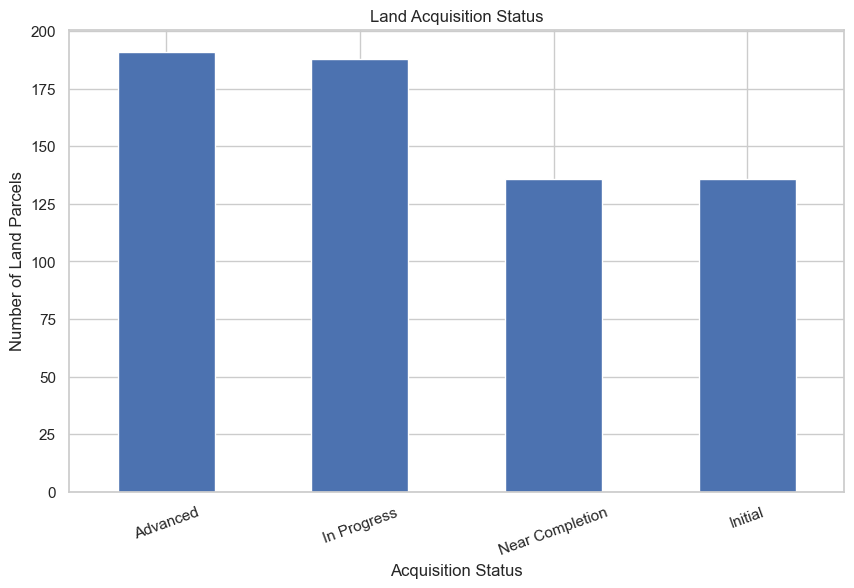

In [77]:
plt.figure(figsize=(10, 6))

df["acquisition_status"].value_counts().plot(
    kind="bar"
)

plt.title("Land Acquisition Status")
plt.xlabel("Acquisition Status")
plt.ylabel("Number of Land Parcels")

plt.xticks(rotation=20)
plt.show()

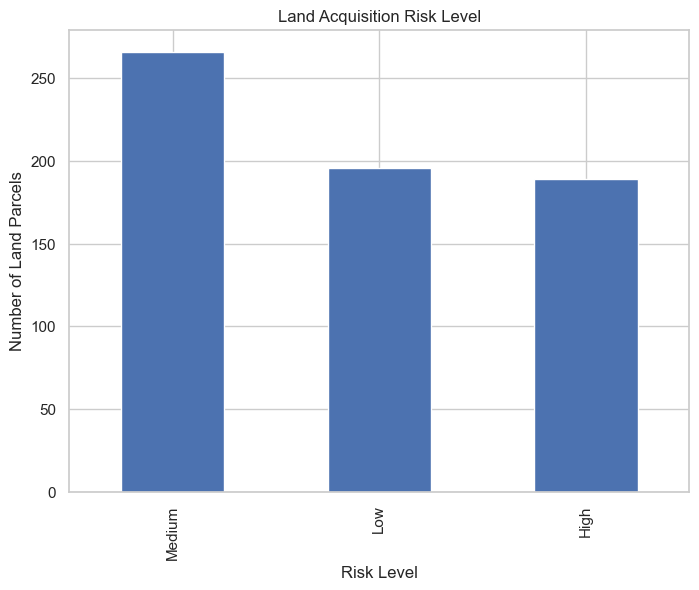

In [78]:
plt.figure(figsize=(8, 6))

df["risk_level"].value_counts().plot(
    kind="bar"
)

plt.title("Land Acquisition Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Number of Land Parcels")

plt.show()

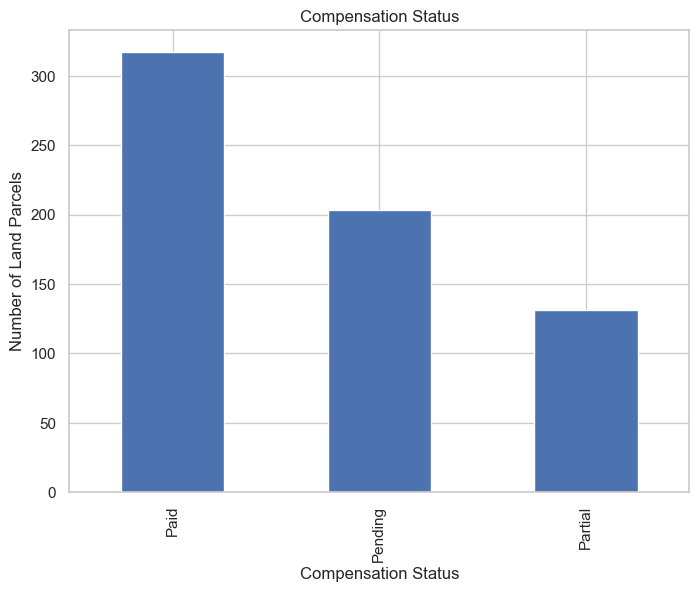

In [79]:
plt.figure(figsize=(8, 6))

df["compensation_status"].value_counts().plot(
    kind="bar"
)

plt.title("Compensation Status")
plt.xlabel("Compensation Status")
plt.ylabel("Number of Land Parcels")

plt.show()

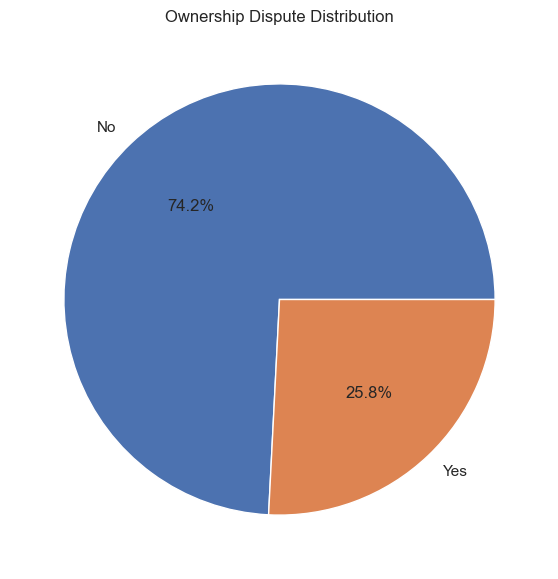

In [80]:
plt.figure(figsize=(7, 7))

df["ownership_dispute"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Ownership Dispute Distribution")
plt.ylabel("")

plt.show()

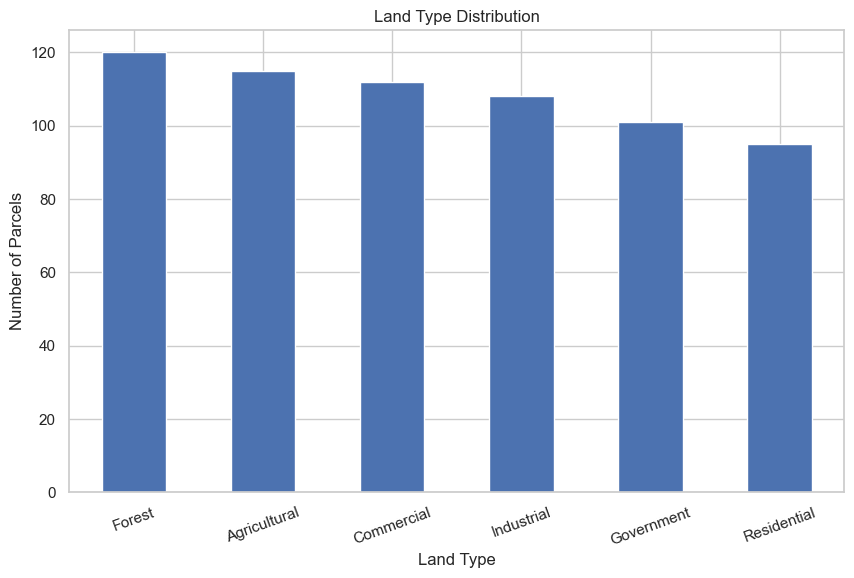

In [81]:
plt.figure(figsize=(10, 6))

df["land_type"].value_counts().plot(
    kind="bar"
)

plt.title("Land Type Distribution")
plt.xlabel("Land Type")
plt.ylabel("Number of Parcels")

plt.xticks(rotation=20)
plt.show()

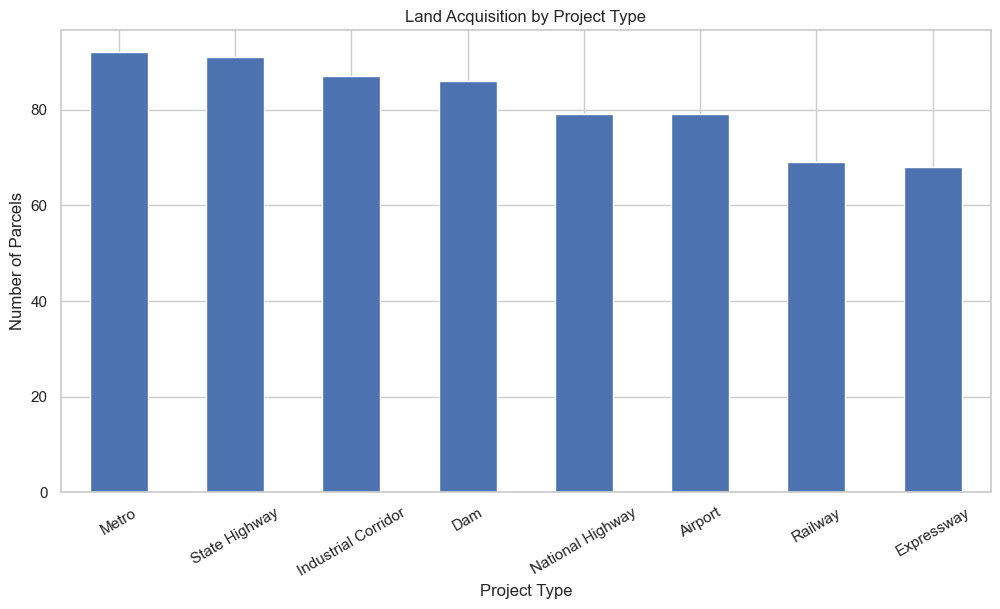

In [82]:
plt.figure(figsize=(12, 6))

df["project_type"].value_counts().plot(
    kind="bar"
)

plt.title("Land Acquisition by Project Type")
plt.xlabel("Project Type")
plt.ylabel("Number of Parcels")

plt.xticks(rotation=30)
plt.show()

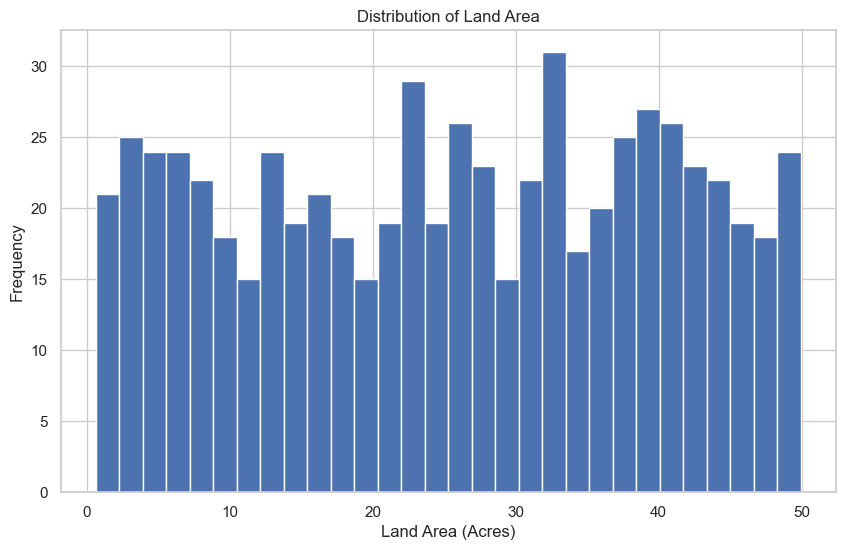

In [83]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["land_area_acres"],
    bins=30
)

plt.title("Distribution of Land Area")
plt.xlabel("Land Area (Acres)")
plt.ylabel("Frequency")

plt.show()

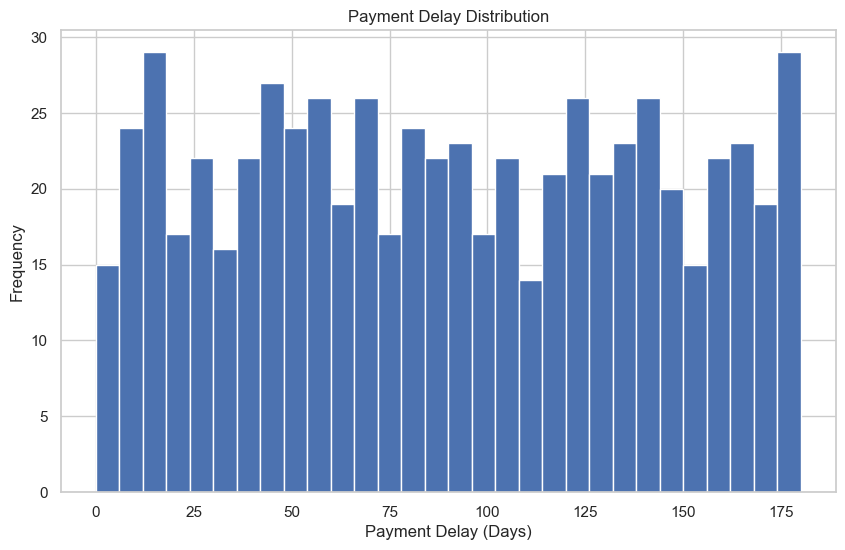

In [84]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["payment_delay_days"],
    bins=30
)

plt.title("Payment Delay Distribution")
plt.xlabel("Payment Delay (Days)")
plt.ylabel("Frequency")

plt.show()

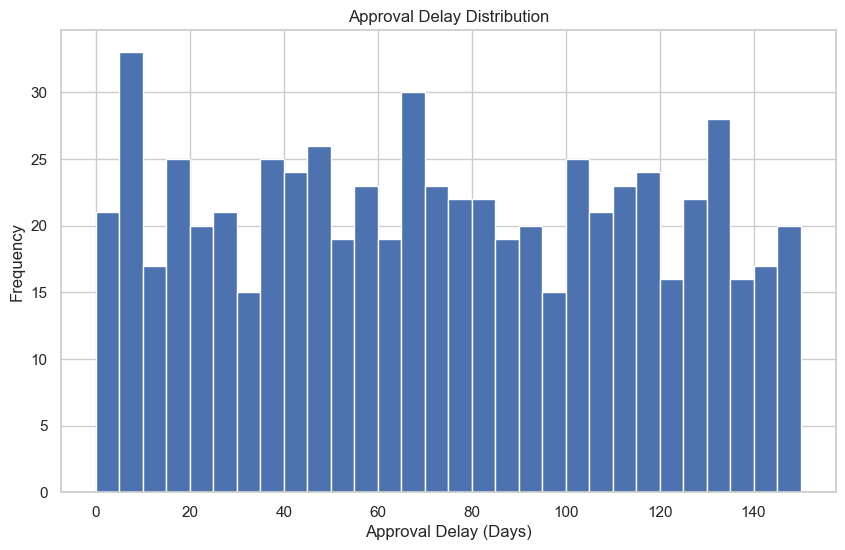

In [85]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["approval_delay_days"],
    bins=30
)

plt.title("Approval Delay Distribution")
plt.xlabel("Approval Delay (Days)")
plt.ylabel("Frequency")

plt.show()

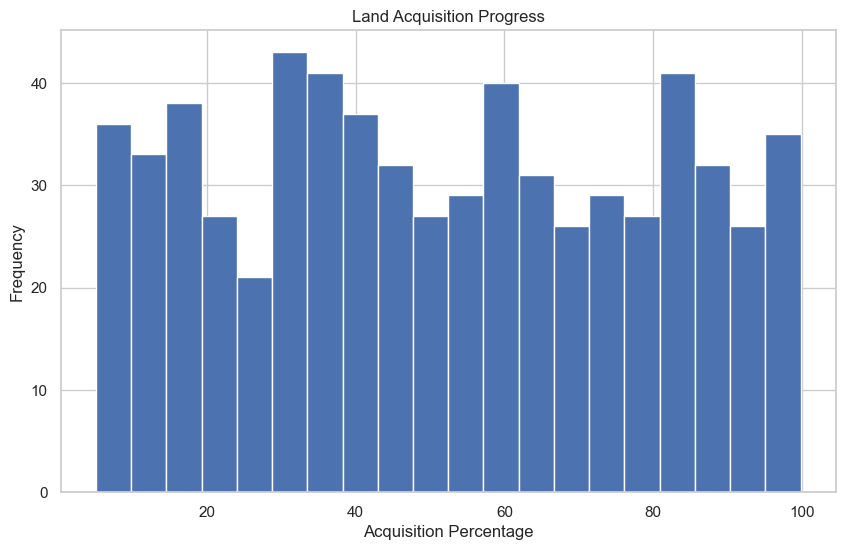

In [86]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["acquisition_percent"],
    bins=20
)

plt.title("Land Acquisition Progress")
plt.xlabel("Acquisition Percentage")
plt.ylabel("Frequency")

plt.show()

In [56]:
district_land = (
    df.groupby("district")["land_area_acres"]
    .sum()
    .sort_values(ascending=False)
)

district_land

district
Karnal                   627.85
Thane                    581.16
 Nizamabad               580.58
Nanded                   557.87
Sarai Rohilla (Delhi)    553.36
Pune                     549.26
Ajmer                    534.72
Bhagalpur                503.09
 Chattarpur (Delhi)      477.91
Ahmednagar               470.27
 Indore                  453.38
Solapur                  443.06
Surat                    442.01
Satara                   427.31
Agra                     424.54
Ludhiana                 400.86
Kanpur                   397.52
Udupi                    393.27
Coimbtore                389.56
Nashik                   381.88
Patna                    381.55
Nagpur                   375.22
patiyala                 356.05
Nagaur                   355.89
Ambala                   354.87
 Mangaluru               353.66
Kapurtala                346.65
Chennai                  341.28
Sangli                   339.03
Varanasi                 338.43
Darbhanga                324.12

In [57]:
print("========== SIH26016 SUMMARY ==========")

print("Total Records:",
      len(df))

print(
    "Total Land Area:",
    round(df["land_area_acres"].sum(), 2),
    "acres"
)

print(
    "Average Acquisition Progress:",
    round(df["acquisition_percent"].mean(), 2),
    "%"
)

print(
    "Average Payment Delay:",
    round(df["payment_delay_days"].mean(), 2),
    "days"
)

print(
    "Average Approval Delay:",
    round(df["approval_delay_days"].mean(), 2),
    "days"
)

print(
    "Ownership Disputes:",
    (df["ownership_dispute"] == "Yes").sum()
)

print(
    "High Risk Parcels:",
    (df["risk_level"] == "High").sum()
)

========== SIH26016 SUMMARY ==========
Total Records: 651
Total Land Area: 16657.49 acres
Average Acquisition Progress: 51.69 %
Average Payment Delay: 89.84 days
Average Approval Delay: 72.59 days
Ownership Disputes: 168
High Risk Parcels: 189
